In [1]:
# Importing libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
health_data = pd.read_csv('/kaggle/input/healthcare/Healthcare.csv') 
health_data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [3]:
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [4]:
health_data.shape

(10000, 15)

In [5]:
health_data.describe()

,Age,Billing Amount,Room Number
count,10000.000000,10000.000000,10000.000000
mean,51.452200,25516.806778,300.082000
std,19.588974,14067.292709,115.806027
min,18.000000,1000.180837,101.000000
25%,35.000000,13506.523967,199.000000
50%,52.000000,25258.112566,299.000000
75%,68.000000,37733.913727,400.000000
max,85.000000,49995.902283,500.000000


In [6]:
health_data.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [7]:
health_data['Medical Condition'].unique()

array(['Diabetes', 'Asthma', 'Obesity', 'Arthritis', 'Hypertension',
       'Cancer'], dtype=object)

In [8]:
health_data['Insurance Provider'].unique()

array(['Medicare', 'UnitedHealthcare', 'Aetna', 'Cigna', 'Blue Cross'],
      dtype=object)

In [9]:
health_data['Admission Type'].unique()

array(['Elective', 'Emergency', 'Urgent'], dtype=object)

In [10]:
health_data['Blood Type'].unique() 

array(['O-', 'O+', 'B-', 'AB+', 'A+', 'AB-', 'A-', 'B+'], dtype=object)

In [11]:
health_data['Gender'].value_counts()

Gender
Female    5075
Male      4925
Name: count, dtype: int64

In [12]:
health_data['Medical Condition'].value_counts()

Medical Condition
Asthma          1708
Cancer          1703
Hypertension    1688
Arthritis       1650
Obesity         1628
Diabetes        1623
Name: count, dtype: int64

In [13]:
health_data['Blood Type'].value_counts()

Blood Type
AB-    1275
AB+    1258
B-     1252
O+     1248
O-     1244
B+     1244
A+     1241
A-     1238
Name: count, dtype: int64

In [14]:
# Performing Exploratory Data Analysis (EDA)

In [15]:
# Distribution of Gender in health data 

<Axes: xlabel='Gender', ylabel='count'>

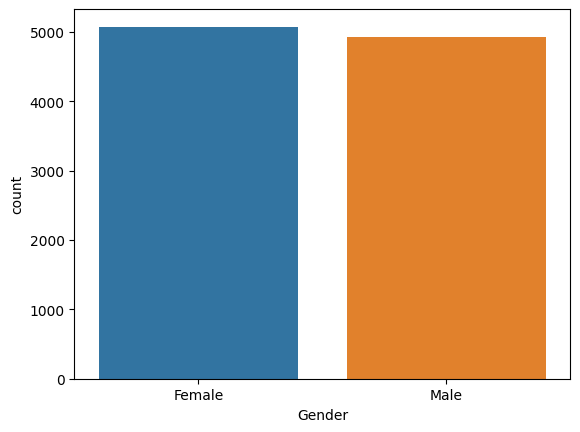

In [16]:
sns.countplot(data=health_data,x='Gender') 

In [17]:
# Distribution of Medical Condition in health data 

<Axes: xlabel='Medical Condition', ylabel='count'>

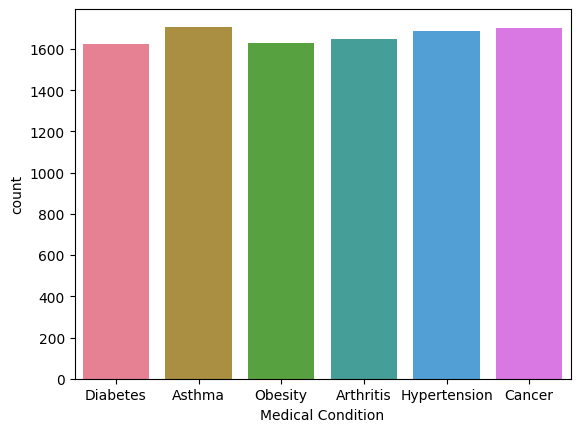

In [18]:
sns.countplot(data=health_data,x='Medical Condition',palette='husl') 

In [19]:
# Distribution of Blood Group in health data 

<Axes: xlabel='Blood Type', ylabel='count'>

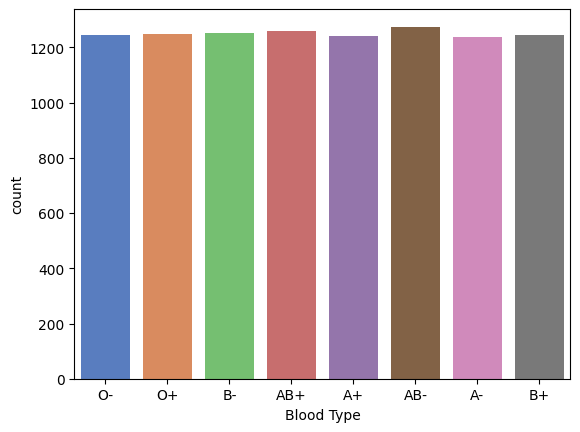

In [20]:
sns.countplot(data=health_data,x='Blood Type',palette='muted') 

In [21]:
# Distribution of Insurance Provider in health data 

<Axes: xlabel='Insurance Provider', ylabel='count'>

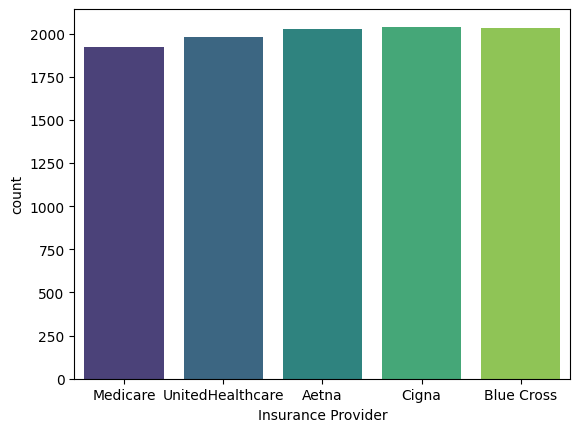

In [22]:
sns.countplot(data=health_data,x='Insurance Provider',palette='viridis') 

In [23]:
# Distribution of Admission Type in health data 

<Axes: xlabel='Admission Type', ylabel='count'>

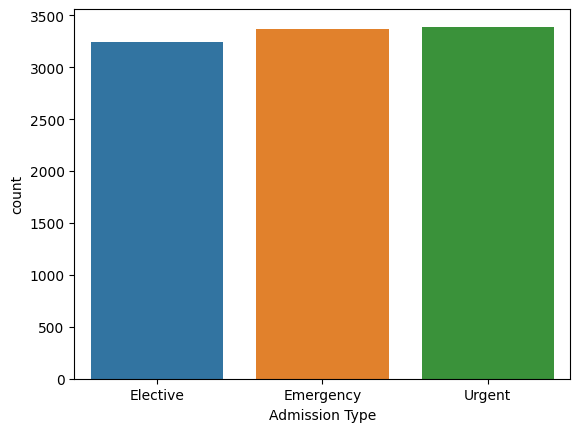

In [24]:
sns.countplot(data=health_data,x='Admission Type') 

In [25]:
# Distribution of Medication in health data 

<Axes: xlabel='Medication', ylabel='count'>

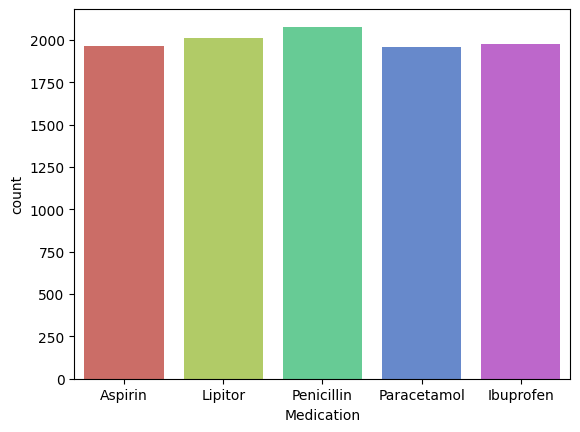

In [26]:
sns.countplot(data=health_data,x='Medication',palette='hls') 

In [27]:
# Plotting Barplot for Age Distribution of patients 

/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


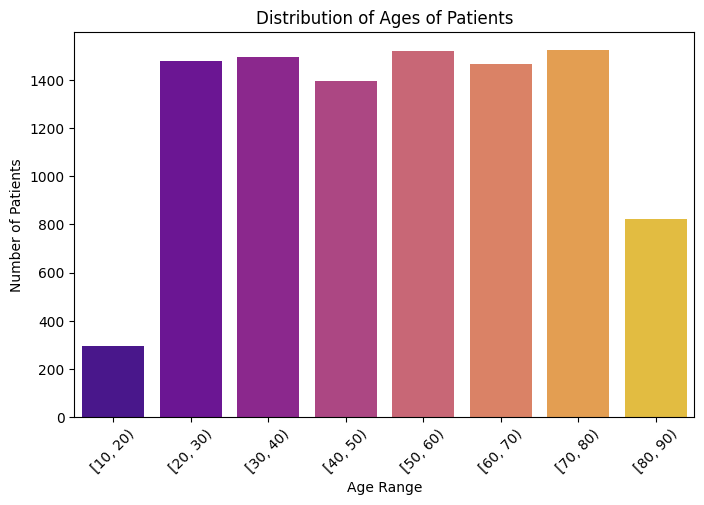

In [28]:
age_ranges = pd.cut(health_data['Age'], bins=range(10, 100, 10), right=False)
plt.figure(figsize=(8,5))
sns.countplot(x=age_ranges,data=health_data,palette='plasma')
plt.title('Distribution of Ages of Patients')
plt.xlabel('Age Range')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

In [29]:
# Distribution of Medical Conditions btw Male and Female

In [30]:
gender_medical = health_data.groupby(['Medical Condition','Gender']).size().sort_values().unstack()
gender_medical 

Gender,Female,Male
Medical Condition,,
Arthritis,815,835
Asthma,874,834
Cancer,887,816
Diabetes,825,798
Hypertension,836,852
Obesity,838,790


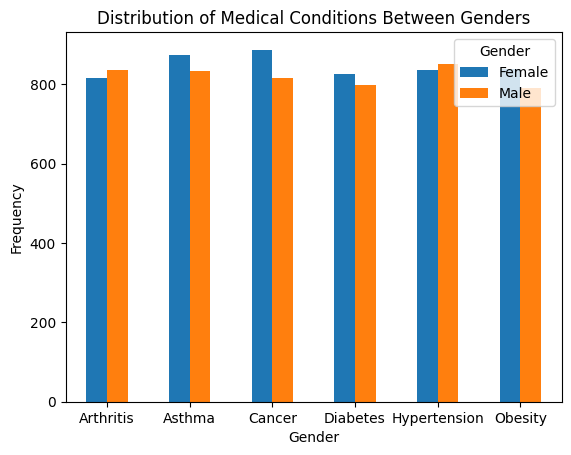

In [31]:
gender_medical.plot(kind = 'bar')
plt.title('Distribution of Medical Conditions Between Genders')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.xticks(rotation = 0)
plt.show() 

In [32]:
# Model Building and Evaluation 

In [33]:
health_data1 = health_data[[ 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Medication', 'Test Results']]
health_data1.head()

,Age,Gender,Blood Type,Medical Condition,Admission Type,Medication,Test Results
0,81,Female,O-,Diabetes,Elective,Aspirin,Inconclusive
1,35,Male,O+,Asthma,Emergency,Lipitor,Normal
2,61,Male,B-,Obesity,Emergency,Lipitor,Normal
3,49,Male,B-,Asthma,Urgent,Penicillin,Abnormal
4,51,Male,O-,Arthritis,Urgent,Paracetamol,Normal


In [34]:
for col in health_data1.columns:
    print(col, health_data1[col].nunique())

Age 68
Gender 2
Blood Type 8
Medical Condition 6
Admission Type 3
Medication 5
Test Results 3


In [35]:
lc = LabelEncoder()
for col in health_data1.columns:
    if col!='Age':
        health_data1[col]=lc.fit_transform(health_data1[col])
health_data1.head() 

/tmp/ipykernel_18/3140869190.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  health_data1[col]=lc.fit_transform(health_data1[col])
/tmp/ipykernel_18/3140869190.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  health_data1[col]=lc.fit_transform(health_data1[col])
/tmp/ipykernel_18/3140869190.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

,Age,Gender,Blood Type,Medical Condition,Admission Type,Medication,Test Results
0,81,0,7,3,0,0,1
1,35,1,6,1,1,2,2
2,61,1,5,5,1,2,2
3,49,1,5,1,2,4,0
4,51,1,7,0,2,3,2


In [36]:
# Set dependent and independent variable 

In [37]:
X = health_data1.drop(['Test Results'],axis=1) 
y = health_data1['Test Results']  

In [38]:
X.head()

,Age,Gender,Blood Type,Medical Condition,Admission Type,Medication
0,81,0,7,3,0,0
1,35,1,6,1,1,2
2,61,1,5,5,1,2
3,49,1,5,1,2,4
4,51,1,7,0,2,3


In [39]:
y.head()

0    1
1    2
2    2
3    0
4    2
Name: Test Results, dtype: int64

In [40]:
# Splitting the data into train and test 

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2) 

In [42]:
# 1. Building Decision Tree Model 

In [43]:
DT_model = DecisionTreeClassifier() 
DT_model.fit(X_train,y_train)

DecisionTreeClassifier()

In [44]:
# Evaluating Decision Tree Model

In [45]:
y_predict = DT_model.predict(X_test) 

In [46]:
# i) Determining Accuracy of the model

In [47]:
accuracy = accuracy_score(y_test,y_predict)
print(f'Accuracy Score : {accuracy}') 

Accuracy Score : 0.3655


In [48]:
# ii) Determine and display Confusion Matrix 

In [49]:
print(confusion_matrix(y_test,y_predict))

[[284 181 200]
 [238 228 206]
 [234 210 219]]


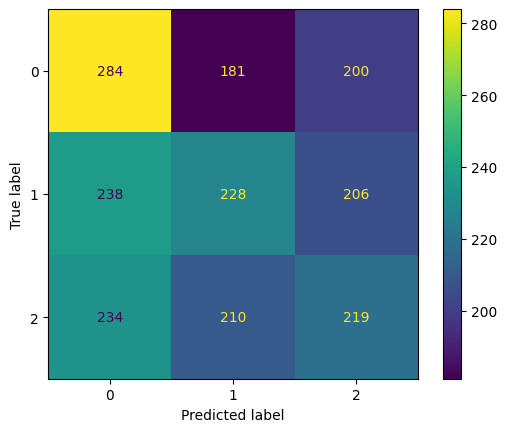

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay 
ConfusionMatrixDisplay.from_estimator(DT_model,X_test,y_test) 

In [51]:
# iii) Determining Classification Report 

In [52]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.38      0.43      0.40       665
           1       0.37      0.34      0.35       672
           2       0.35      0.33      0.34       663

    accuracy                           0.37      2000
   macro avg       0.36      0.37      0.36      2000
weighted avg       0.36      0.37      0.36      2000



In [53]:
# 2. Building Random Forest Model 

In [54]:
RF_model = RandomForestClassifier(n_estimators=30,random_state=12) 
RF_model.fit(X_train,y_train) 

RandomForestClassifier(n_estimators=30, random_state=12)

In [55]:
# Evaluating Random Forest Model

In [56]:
y_predict = RF_model.predict(X_test) 

In [57]:
accuracy = accuracy_score(y_test,y_predict)
print(f'Accuracy Score : {accuracy}') 

Accuracy Score : 0.347


In [58]:
# ii) Determine and display Confusion Matrix 

In [59]:
print(confusion_matrix(y_test,y_predict)) 

[[258 210 197]
 [257 218 197]
 [247 198 218]]


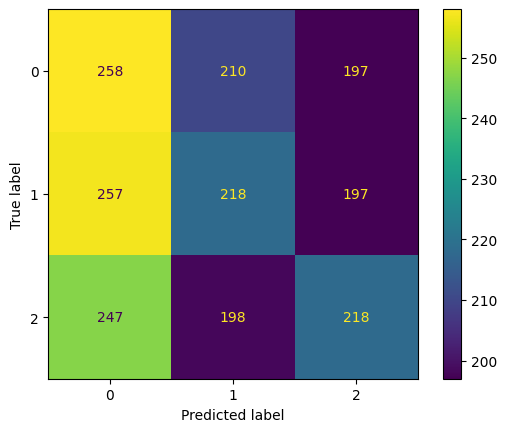

In [60]:
ConfusionMatrixDisplay.from_estimator(RF_model,X_test,y_test) 

In [61]:
# iii) Determining Classification Report 

In [62]:
print(classification_report(y_test,y_predict)) 

              precision    recall  f1-score   support

           0       0.34      0.39      0.36       665
           1       0.35      0.32      0.34       672
           2       0.36      0.33      0.34       663

    accuracy                           0.35      2000
   macro avg       0.35      0.35      0.35      2000
weighted avg       0.35      0.35      0.35      2000



In [63]:
# 3. Building Logistic Regression Model

In [64]:
LR_model = LogisticRegression() 
LR_model.fit(X_train,y_train) 

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [65]:
# Evaluating Logistic Regression Model

In [66]:
y_predict = LR_model.predict(X_test)

In [67]:
# i) Determining Accuracy Score of the model

In [68]:
accuracy = accuracy_score(y_test,y_predict)
print(f'Accuracy Score : {accuracy}') 

Accuracy Score : 0.342


In [69]:
# ii) Determine and display Confusion Matrix

In [70]:
print(confusion_matrix(y_test,y_predict))

[[487  70 108]
 [478  86 108]
 [481  71 111]]


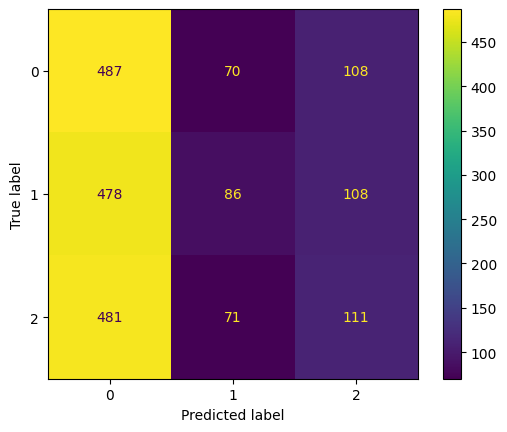

In [71]:
ConfusionMatrixDisplay.from_estimator(LR_model,X_test,y_test) 

In [72]:
# iii) Determining Classification Report 

In [73]:
print(classification_report(y_test,y_predict)) 

              precision    recall  f1-score   support

           0       0.34      0.73      0.46       665
           1       0.38      0.13      0.19       672
           2       0.34      0.17      0.22       663

    accuracy                           0.34      2000
   macro avg       0.35      0.34      0.29      2000
weighted avg       0.35      0.34      0.29      2000

